In [ ]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from ydata_profiling import ProfileReport

from utils import *
from schemas import *
from processing import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
SEED=42

# Načtení dat

### Data z měřících přístrojů

In [ ]:
df_all = cast_mereni(pl.read_parquet('kod/data/data_z_mericich_pristroju/parquet/nafta_osobni', schema=nafta_schema)).sample(fraction=1.0, shuffle=True, seed=SEED)
short_display(df_all)
display_counts(df_all)
df_all.head(1)

(7584204, 143)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek,Benzin_PocetVyusteni,Plyn_PocetVyusteni,Obd_Readiness_J1939_Pritomno,Obd_Readiness_Zazeh_Pritomno
0,CZ-440114-23-07-0254,2023-07-11,440114,2023-07-11 08:48:36.197,2023-07-11 09:11:53.243,50975,CZ-440114-23-07-0254,2023-07-11 09:11:50.822152,Bosch,BEA 950,...,5001.0,1.0,849.0,1.0,82.0,2.0,0,0,False,False
1,CZ-530507-21-05-0096,2021-05-07,530507,2021-05-07 11:48:28.930,2021-05-07 11:55:08.443,18917,CZ-530507-21-05-0096,2021-05-07 11:51:00.000000,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
2,CZ-421134-21-07-0671,2021-07-27,421134,2021-07-27 09:01:39.600,2021-07-27 09:14:32.120,42887,CZ-421134-21-07-0671,2021-07-27 00:00:00.000000,ActiaCZ,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
3,CZ-540514-20-10-3339,2020-10-21,540514,2020-10-21 14:56:09.460,2020-10-21 15:05:56.360,34771,CZ-540514-20-10-3339,2020-10-21 14:59:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
4,CZ-430834-19-05-0140,2019-05-13,430834,2019-05-13 08:17:12.950,2019-05-13 08:46:57.340,9855,CZ-430834-19-05-0140,2019-05-13 08:23:00.000000,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
5,CZ-480933-23-11-0056,2023-11-03,480933,2023-11-03 09:19:03.677,2023-11-03 09:35:01.523,49817,CZ-480933-23-11-0056,2023-11-03 09:25:00.000000,ATAL s.r.o.,AT605,...,4230.0,1.0,810.0,1.0,70.0,1.0,0,0,False,False
6,CZ-410907-20-04-0332,2020-04-22,410907,2020-04-22 14:36:34.107,2020-04-22 14:48:05.310,42311,CZ-410907-20-04-0332,2020-04-22 14:36:34.000000,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
7,CZ-571305-23-09-0019,2023-09-18,571305,2023-09-18 09:07:49.550,2023-09-18 09:13:31.767,44159,CZ-571305-23-09-0019,2023-09-18 09:13:26.463085,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
8,CZ-480410-25-08-0083,2025-08-21,480410,2025-08-21 09:54:11.507,2025-08-21 10:05:43.093,106207,CZ-480410-25-08-0083,2025-08-21 10:04:00.000000,MAHLE,OPA-100,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
9,CZ-480558-25-09-0381,2025-09-08,480558,2025-09-08 11:35:12.640,2025-09-08 11:47:17.650,89487,CZ-480558-25-09-0381,2025-09-08 11:38:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False


CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Poznamky,Vozidlo_Vin,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Vozidlo_CisloMotoru,Vozidlo_Odometer,Vozidlo_RokVyroby,Vozidlo_DatumPrvniRegistrace,Vozidlo_Palivo,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotka,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Vysledek_TesnostPlynovehoZarizeni,Vysledek_Vyhovuje,PristiProhlidka,EmisniSystem,Obd_KomunikacniProtokol,Obd_Vin,Obd_PocetDtc,Obd_VzdalenostDtc,Obd_CasDtc,Obd_KontrolaMil,Obd_VypisDtc,Zavady,Obd_Readiness_Vysledek,Obd_Readiness_Vznet_AC_Podporovano,Obd_Readiness_Vznet_AC_Otestovano,Obd_Readiness_Vznet_BOOST_Podporovano,Obd_Readiness_Vznet_BOOST_Otestovano,Obd_Readiness_Vznet_COMP_Podporovano,Obd_Readiness_Vznet_COMP_Otestovano,Obd_Readiness_Vznet_DPF_Podporovano,Obd_Readiness_Vznet_DPF_Otestovano,Obd_Readiness_Vznet_EGR-VVT_Podporovano,Obd_Readiness_Vznet_EGR-VVT_Otestovano,Obd_Readiness_Vznet_EGS_Podporovano,Obd_Readiness_Vznet_EGS_Otestovano,Obd_Readiness_Vznet_FUEL_Podporovano,Obd_Readiness_Vznet_FUEL_Otestovano,Obd_Readiness_Vznet_MISF_Podporovano,Obd_Readiness_Vznet_MISF_Otestovano,Obd_Readiness_Vznet_NMHC_Podporovano,Obd_Readiness_Vznet_NMHC_Otestovano,Obd_Readiness_Vznet_NOX_Podporovano,Obd_Readiness_Vznet_NOX_Otestovano,Obd_Readiness_Vznet_RESERVE_Podporovano,Obd_Readiness_Vznet_RESERVE_Otestovano,Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota,Nafta_MereniVznetLimit_OtackyVolnobezne_Min_RucniZadani,Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota,Nafta_MereniVznetLimit_OtackyVolnobezne_Max_RucniZadani,Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota,Nafta_MereniVznetLimit_OtackyPrebehove_Min_RucniZadani,Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota,Nafta_MereniVznetLimit_OtackyPrebehove_Max_RucniZadani,Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota,Nafta_MereniVznetLimit_CasAkcelerace_Max_RucniZadani,Nafta_MereniVznetLimit_Kourivost_Max_Hodnota,Nafta_MereniVznetLimit_Kourivost_Max_RucniZadani,Nafta_MereniVznetLimit_KourivostRozpeti_Max_Hodnota,Nafta_MereniVznetLimit_KourivostRozpeti_Max_RucniZadani,Nafta_Palivo,Nafta_PocetVyusteni,Nafta_MereniPrumer_TPS_Hodnota,Nafta_MereniPrumer_TPS_Vysledek,Nafta_MereniPrumer_CasAkcelerace_Hodnota,Nafta_MereniPrumer_CasAkcelerace_Vysledek,Nafta_MereniPrumer_Kourivost_Hodnota,Nafta_MereniPrumer_Kourivost_Vysledek,Nafta_MereniPrumer_OtackyPrebehove_Hodnota,Nafta_MereniPrumer_OtackyPrebehove_Vysledek,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota,Nafta_MereniPrumer_OtackyVolnobezne_Vysledek,Nafta_MereniPrumer_Teplota_Hodnota,Nafta_MereniPrumer_Teplota_Vysledek,Nafta_Mereni0_TPS_Hodnota,Nafta_Mereni0_TPS_Vysledek,Nafta_Mereni0_CasAkcelerace_Hodnota,Nafta_Mereni0_CasAkcelerace_Vysledek,Nafta_Mereni0_Kourivost_Hodnota,Nafta_Mereni0_Kourivost_Vysledek,Nafta_Mereni0_OtackyPrebehove_Hodnota,Nafta_Mereni0_OtackyPrebehove_Vysledek,Nafta_Mereni0_OtackyVolnobezne_Hodnota,Nafta_Mereni0_OtackyVolnobezne_Vysledek,Nafta_Mereni0_Teplota_Hodnota,Nafta_Mereni0_Teplota_Vysledek,Nafta_Mereni1_TPS_Hodnota,Nafta_Mereni1_TPS_Vysledek,Nafta_Mereni1_CasAkcelerace_Hodnota,Nafta_Mereni1_CasAkcelerace_Vysledek,Nafta_Mereni1_Kourivost_Hodnota,Nafta_Mereni1_Kourivost_Vysledek,Nafta_Mereni1_OtackyPrebehove_Hodnota,Nafta_Mereni1_OtackyPrebehove_Vysledek,Nafta_Mereni1_OtackyVolnobezne_Hodnota,Nafta_Mereni1_OtackyVolnobezne_Vysledek,Nafta_Mereni1_Teplota_Hodnota,Nafta_Mereni1_Teplota_Vysledek,Nafta_Mereni2_TPS_Hodnota,Nafta_Mereni2_TPS_Vysledek,Nafta_Mereni2_CasAkcelerace_Hodnota,Nafta_Mereni2_CasAkcelerace_Vysledek,Nafta_Mereni2_Kourivost_Hodnota,Nafta_Mereni2_Kourivost_Vysledek,Nafta_Mereni2_OtackyPrebehove_Hodnota,Nafta_Mereni2_OtackyPrebehove_Vysledek,Nafta_Mereni2_OtackyVolnobezne_Hodnota,Nafta_Mereni2_OtackyVolnobezne_Vysledek,Nafta_Mereni2_Teplota_Hodnota,Nafta_Mereni2_Teplota_Vysled

### Prohlidky vozidel STK a SME

In [14]:
df_technicka = cast_prohlidka(pl.read_parquet('kod/data/prohlidky_vozidel_stk_a_sme/parquet/prohlidky', schema=prohlidky_schema))
short_display(df_technicka)
display_counts(df_technicka)
df_technicka.head(1)

: 

# Filtrace osobních vozidel

In [ ]:
df = df_all.join(df_technicka[['CisloProtokolu', 'Vozidlo_Vin', 'Vozidlo_Kategorie', 'Emise_CisloProtokolu']], on='CisloProtokolu', how='left')
short_display(df, 100)
df['Vozidlo_Vin', 'Vozidlo_Vin_right'].filter(pl.col('Vozidlo_Vin') != pl.col('Vozidlo_Vin_right'))

(10533682, 146)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek,Benzin_PocetVyusteni,Plyn_PocetVyusteni,Obd_Readiness_J1939_Pritomno,Obd_Readiness_Zazeh_Pritomno,Vozidlo_Vin_right,Vozidlo_Kategorie,Emise_CisloProtokolu
0,CZ-450602-19-03-1123,2019-03-28,450602,2019-03-28 12:41:08.970,2019-03-28 12:57:40.743,36365,CZ-450602-19-03-1123,2019-03-28 12:44:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,0,0,False,False,VSSZZZ1PZ8R062528,M1,CZ-450602-19-03-1123
1,CZ-261101-21-08-0032,2021-08-05,261101,2021-08-05 15:25:34.563,2021-08-05 15:37:12.120,61029,CZ-261101-21-08-0032,2021-08-05 15:25:35.000000,Bosch,BEA070,...,NaN,NaN,NaN,0,0,False,False,TMBAG7NE9E0010479,M1,CZ-261101-21-08-0032
2,CZ-430831-20-11-0442,2020-11-19,430831,2020-11-19 09:37:15.600,2020-11-19 10:00:48.867,29421,CZ-430831-20-11-0442,2020-11-19 09:53:00.000000,Bosch,BEA070,...,NaN,NaN,NaN,0,0,False,False,WF05XXGBB54A46002,M1,CZ-430831-20-11-0442
3,CZ-450532-24-11-0705,2024-11-15,450532,2024-11-15 08:29:09.530,2024-11-15 08:45:50.440,36737,CZ-450532-24-11-0705,2024-11-15 08:45:43.917807,Bosch,BEA070,...,NaN,NaN,NaN,0,0,False,False,ZCFA1EG0402582282,N2,CZ-450532-24-11-0705
4,CZ-530120-19-01-0116,2019-01-10,530120,2019-01-10 17:18:39.870,2019-01-10 17:44:43.040,36399,CZ-530120-19-01-0116,2019-01-10 17:21:00.000000,BRAIN BEE,OPA-100,...,NaN,NaN,NaN,0,0,False,False,1J8GLN8792W242413,M1,CZ-530120-19-01-0116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,CZ-461132-19-08-0164,2019-08-12,461132,2019-08-12 11:33:33.930,2019-08-12 11:56:28.283,407,CZ-461132-19-08-0164,2019-08-12 11:42:00.000000,ActiaCZ,AT605,...,NaN,NaN,NaN,0,0,False,False,TMBJS25JXC3029729,M1,CZ-461132-19-08-0164
96,CZ-440709-21-03-0667,2021-03-23,440709,2021-03-23 09:28:49.867,2021-03-23 09:33:56.687,37145,CZ-440709-21-03-0667,2021-03-23 09:31:00.000000,Bosch,RTM430,...,NaN,NaN,NaN,0,0,False,False,TMBAH7NP9H7509907,M1,CZ-440709-21-03-0667
97,CZ-420940-21-06-0944,2021-06-28,420940,2021-06-28 10:07:58.657,2021-06-28 10:14:37.063,36537,CZ-420940-21-06-0944,2021-06-28 00:00:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,0,0,False,False,WV2ZZZ7HZ9H066962,M1,CZ-420940-21-06-0944
98,CZ-420932-22-02-0207,2022-02-08,420932,2022-02-08 13:41:24.680,2022-02-08 13:49:51.313,49769,CZ-420932-22-02-0207,2022-02-08 13:48:36.010325,Bosch,BEA 950,...,NaN,NaN,NaN,0,0,False,False,TMBGS26Y764559628,M1,CZ-420932-22-02-0207


Vozidlo_Vin,Vozidlo_Vin_right
str,str
"""WOLBD8EG2H8017301""","""W0LBD8EG2H8017301"""
"""ZCFA71MM202667581""","""ZCFA71MN202667581"""
"""1""","""SALLTGM883A794099"""
"""TMBAG7NE1HO167637""","""TMBAG7NE1H0167637"""
"""WAB5C91010G673612""","""WBA5C91010G673612"""
…,…
"""YMDA""","""WF0FXXWPMFLY76560"""
"""VF1JK0EDC37008942""","""SB1KW20E00F010981"""
"""WVWVZZZ3CZEE07047""","""WVWZZZ3CZEE070470"""


In [13]:
short_display(df.filter(pl.col('Emise_CisloProtokolu').is_null()))

(505293, 146)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek,Benzin_PocetVyusteni,Plyn_PocetVyusteni,Obd_Readiness_J1939_Pritomno,Obd_Readiness_Zazeh_Pritomno,Vozidlo_Vin_right,Vozidlo_Kategorie,Emise_CisloProtokolu
0,CZ-003534-22-12-0302,2022-12-21,3534,2022-12-21 09:44:32.957,2022-12-21 10:01:14.303,27301,CZ-003534-22-12-0302,2022-12-21 09:59:00.000000,ACTIA CZ s.r.o.,AT605,...,NaN,NaN,NaN,0,0,False,False,None,None,None
1,CZ-003726-25-08-0221,2025-08-12,3726,2025-08-12 09:00:29.407,2025-08-12 09:20:59.310,69259,CZ-003726-25-08-0221,2025-08-12 09:00:29.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,0,0,False,False,None,None,None
2,CZ-003618-22-11-1006,2022-11-14,3618,2022-11-14 12:57:52.950,2022-11-14 13:12:57.960,6615,CZ-003618-22-11-1006,2022-11-14 13:06:29.619642,Bosch,BEA 950,...,NaN,NaN,NaN,0,0,False,False,None,None,None
3,CZ-003250-24-09-1435,2024-09-26,3250,2024-09-26 13:09:41.843,2024-09-26 13:16:04.610,72221,CZ-003250-24-09-1435,2024-09-26 13:09:41.000000,AVL DiTEST GmbH,DSS OM-CZ,...,NaN,NaN,NaN,0,0,False,False,None,None,None
4,CZ-003535-25-02-0274,2025-02-12,3535,2025-02-12 14:22:31.487,2025-02-12 14:42:07.077,4501,CZ-003535-25-02-0274,2025-02-12 14:32:20.352214,Bosch,BEA 950,...,1.0,81.0,2.0,0,0,False,False,None,None,None
5,CZ-003515-21-12-0137,2021-12-09,3515,2021-12-09 12:11:51.857,2021-12-09 12:25:16.010,2581,CZ-003515-21-12-0137,2021-12-09 12:21:00.000000,ACTIA CZ s.r.o.,AT605,...,NaN,NaN,NaN,0,0,False,False,None,None,None
6,CZ-003758-22-07-0247,2022-07-12,3758,2022-07-12 11:09:22.590,2022-07-12 11:15:14.790,93979,CZ-003758-22-07-0247,2022-07-12 11:15:12.436205,Bosch,BEA 950,...,1.0,83.0,2.0,0,0,False,False,None,None,None
7,CZ-003106-23-06-2134,2023-06-29,3106,2023-06-29 14:24:24.843,2023-06-29 14:33:13.340,36471,CZ-003106-23-06-2134,2023-06-29 14:33:12.248776,Bosch,BEA 950,...,NaN,NaN,NaN,0,0,False,False,None,None,None
8,CZ-003756-24-11-0482,2024-11-25,3756,2024-11-25 07:52:09.013,2024-11-25 08:16:52.497,3023,CZ-003756-24-11-0482,2024-11-25 07:52:09.000000,AVL DiTEST GmbH,DSS OM-CZ,...,NaN,NaN,NaN,0,0,False,False,None,None,None
9,CZ-003206-23-08-1004,2023-08-28,3206,2023-08-28 15:23:42.597,2023-08-28 15:26:51.067,27335,CZ-003206-23-08-1004,2023-08-28 15:26:49.329271,Bosch,BEA 950,...,NaN,NaN,NaN,0,0,False,False,None,None,None


In [ ]:
df_technicka.filter(pl.col('CisloProtokolu') == 'CZ-3534-22-12-0302')

CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,Prohlidka_Ukonceni,AdministrativniOprava_CisloProtokolu,AdministrativniOprava_DatumProhlidky,Vozidlo_Vin,Vozidlo_Druh,Vozidlo_Kategorie,Vozidlo_Provedeni,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Registrace_DatumPrvni,Registrace_Stat,Registrace_CisloDokladu,Emise_CisloProtokolu,Emise_DatumProhlidky,Emise_Stanice_Cislo,Emise_Stanice_Kraj,Emise_Stanice_ORP,Emise_Stanice_Obec,Emise_Zahajeni,Emise_Ukonceni,Emise_OdpovednaOsoba,Emise_ZakladniPalivo,Emise_AlternativniPalivo,Emise_EmisniSystem,Emise_VyrobceMotoru,Emise_CisloMotoru,Emise_RokVyroby,Technicka_Zahajeni,Technicka_Ukonceni,Technicka_OdpovednaOsoba,Adr_Zahajeni,Adr_Ukonceni,Adr_OdpovednaOsoba,Adr_Platnost_Periodicka,Adr_Platnost_Meziperiodicka,Adr_KodCisterny,Adr_CisloOsvedceni,Adr_ZavadyText,Adr_Poznamka,Tsk_Zahajeni,Tsk_Ukonceni,Tsk_OdpovednaOsoba,Vysledek_Odometr,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""CZ-3534-22-12-0302""","""2022-12-21""","""Pravidelná""","""Plný""","""27301""","""3534""","""Ústecký kraj""","""Děčín""","""Děčín""","""2022-12-21T09:38:06.8830000+01…","""2022-12-21T10:51:20.6200000+01…",null,null,"""TMBUH61Z7B2050637""","""OSOBNÍ AUTOMOBIL""","""M1""",null,"""ŠKODA""","""OCTAVIA COMBI (1Z)""","""CEG""","""2010-11-08T00:00:00.0000000+01…","""Česká republika""","""UM425286""","""CZ-003534-22-12-0302""","""2022-12-21T10:51:20.6200000+01…","""3534""",null,null,null,"""2022-12-21T09:44:32.9570000+01…","""2022-12-21T10:01:14.3030000+01…","""27301""","""Nafta""",null,"""Řízený s OBD""",null,null,null,"""2022-12-21T10:12:33.0000000+01…","""2022-12-21T10:46:22.0000000+01…","""27301""",null,null,null,null,null,null,null,null,null,null,null,null,"""334737""",null,"""2024-12-21""","""true""","""1"""


# Kontrola konzistence dat
## CisloProtokolu
Drtivá většina protokolů má unikátní čílo.  
Vzácně je celý řádek duplicitně uvedený.
Pouze v jednotlivých případech se čísla protokolů shodují při neidentických ostatních polích - stejný protokol evidován na dvou různých staanicích.

In [39]:
short_display(df['CisloProtokolu'].value_counts().sort(by='count', descending=True).filter(pl.col('count') != 1))
non_duplicit_redundant = df.unique()['CisloProtokolu'].value_counts().sort(by='count', descending=True).filter(pl.col('count') != 1)
short_display(df.join(non_duplicit_redundant, on='CisloProtokolu', how='semi'))

(417, 2)


,CisloProtokolu,count
0,CZ-421036-25-03-0359,2
1,CZ-530605-21-10-0029,2
2,CZ-530114-25-03-0693,2
3,CZ-471416-21-10-0006,2
4,CZ-570228-21-10-0208,2
5,CZ-450402-25-03-0584,2
6,CZ-580312-25-03-0181,2
7,CZ-480828-21-10-0162,2
8,CZ-480236-21-10-0102,2
9,CZ-430307-21-10-0089,2


(4, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-550309-23-06-0452,2023-06-14,3521,2023-06-14 14:29:49.537,2023-06-14 15:01:31.037,3329,CZ-550309-23-06-0452,2023-06-14 14:50:00.000000,MAHLE,OPA-100,...,1.18,1.0,0.51,1.0,2130.0,1.0,600.0,1.0,80.0,1.0
1,CZ-550309-23-06-0452,2023-06-14,550309,2023-06-14 14:29:49.537,2023-06-14 15:01:31.037,2565,CZ-550309-23-06-0452,2023-06-14 14:50:00.000000,MAHLE,OPA-100,...,1.18,1.0,0.51,1.0,2130.0,1.0,600.0,1.0,80.0,1.0
2,CZ-540308-24-02-0512,2024-02-14,540308,2024-02-14 06:53:19.297,2024-02-14 07:09:35.900,102209,CZ-540308-24-02-0512,2024-02-14 07:08:34.888717,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CZ-540308-24-02-0512,2024-02-14,3420,2024-02-14 06:53:19.297,2024-02-14 07:09:35.900,69281,CZ-540308-24-02-0512,2024-02-14 07:08:34.888717,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Neshoda mezi číslem protokolu a číslem protokolu prohlídky nastává zřídka. Nesoulad je způsoben vystavením samostatného protokolu namísto přiložení emistní kontroly pouze jako přílohy k technické kontrole. Pouze minimum protokolů dokonce bylo vystaveno na jiné stanici.

In [44]:
different_protocols = df.filter(pl.col('CisloProtokolu') != pl.col('Prohlidka_CisloProtokolu'))
short_display(different_protocols)
print(f'Podíl případů s odlišným číslem protokolu technické prohlídky a měření emisí {different_protocols.height / df.height * 100:.2f} %')
short_display(different_protocols.filter(pl.col('CisloProtokolu').str.split('-').list.get(1) != pl.col('Prohlidka_CisloProtokolu').str.split('-').list.get(1)))

(48137, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-480236-23-08-0126,2023-08-16,480236,NaT,NaT,42021,CZ-480236-23-08-0125,2023-08-16 08:04:31.795370,Bosch,BEA 950,...,3.02,1.0,0.21,1.0,5410.0,1.0,790.0,1.0,81.0,2.0
1,CZ-470508-21-08-0469,2021-08-27,470508,NaT,NaT,40529,CZ-470508-21-08-0464,2021-08-27 08:16:00.000000,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CZ-560401-21-08-0102,2021-08-20,560401,NaT,NaT,40169,CZ-560401-21-08-0099,2021-08-20 07:41:00.000000,ActiaCZ,AT605,...,0.77,1.0,1.04,1.0,2630.0,1.0,990.0,1.0,76.0,1.0
3,CZ-410432-21-04-0143,2021-04-13,410432,NaT,NaT,42475,CZ-410432-21-04-0142,2021-04-13 07:39:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CZ-420117-22-11-0718,2022-11-16,420117,NaT,NaT,40451,CZ-420117-22-11-0219,2022-11-04 07:27:31.472519,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CZ-461135-22-10-0391,2022-10-19,461135,NaT,NaT,94189,CZ-461135-22-10-0188,2022-10-11 11:14:14.934949,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CZ-481020-22-03-0471,2022-03-21,481020,NaT,NaT,43271,CZ-481020-22-03-0468,2022-03-21 10:46:49.708564,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,CZ-411033-19-11-0389,2019-11-18,411033,NaT,NaT,34289,CZ-411033-19-11-0386,2019-11-18 11:23:00.000000,ActiaCZ,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,CZ-560616-19-03-0205,2019-03-12,560616,NaT,NaT,14053,CZ-560616-19-03-0204,2019-03-12 12:17:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,1.67,1.0,0.03,1.0,5100.0,1.0,800.0,1.0,60.0,1.0
9,CZ-430427-25-10-0906,2025-10-30,430427,NaT,NaT,39225,CZ-430427-25-10-0903,2025-10-30 12:56:00.000000,ATAL s.r.o.,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Podíl případů s odlišným číslem protokolu technické prohlídky a měření emisí 0.47 %
(164, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-470518-22-07-0030,2022-07-11,470518,NaT,NaT,40437,CZ-570523-22-07-0007,2022-07-01 12:27:00.000000,SUN,DGA 1500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CZ-550309-23-05-0293,2023-05-17,550309,NaT,NaT,12637,CZ-440709-22-05-2029,2022-05-31 13:57:46.272814,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CZ-571109-23-01-0169,2023-01-11,571109,NaT,NaT,872,CZ-460243-17-11-0333,2017-11-30 10:34:00.000000,Bosch,RTM430,...,1.69,1.0,0.05,1.0,4332.0,1.0,747.0,1.0,0.0,1.0
3,CZ-440916-22-02-0462,2022-02-18,440916,NaT,NaT,26703,CZ-560406-20-02-0302,2020-02-20 08:24:17.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,2.45,1.0,0.11,1.0,5040.0,1.0,900.0,1.0,NaN,NaN
4,CZ-140701-22-12-0197,2022-12-16,140701,NaT,NaT,37769,CZ-420422-20-03-0313,2020-03-13 05:39:00.000000,Bosch,RTM430,...,3.74,1.0,0.29,1.0,4907.0,1.0,830.0,1.0,0.0,1.0
5,CZ-411040-21-06-0721,2021-06-29,411040,NaT,NaT,37269,CZ-480348-19-03-0020,2019-03-06 14:28:00.000000,ActiaCZ,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CZ-440916-19-06-0460,2019-06-17,440916,NaT,NaT,37193,CZ-580508-19-02-0208,2019-02-18 12:24:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,1.61,1.0,2.50,1.0,3270.0,1.0,790.0,1.0,70.0,1.0
7,CZ-440704-21-11-0030,2021-11-01,440704,NaT,NaT,34767,CZ-540514-19-11-3559,2019-11-25 10:40:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,1.68,1.0,0.55,1.0,5060.0,1.0,850.0,1.0,82.0,1.0
8,CZ-481004-20-03-0012,2020-03-04,481004,NaT,NaT,36987,CZ-481012-19-03-0033,2019-03-13 08:28:00.000000,BRAIN BEE,OPA-100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,CZ-430215-23-05-0301,2023-05-23,430215,NaT,NaT,2283,CZ-430216-23-04-0283,2023-04-26 14:23:08.160038,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ve vzácných případech neodpovídá nekoresponduje druhá část čísla protokolu s číslem stanice.

In [5]:
short_display(df.filter(pl.col('CisloProtokolu').str.split('-').list.get(1).str.to_integer(dtype=pl.Int32) != pl.col('StaniceCislo')))

(2, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-550309-23-06-0452,2023-06-14,3521,2023-06-14 14:29:49.537,2023-06-14 15:01:31.037,3329,CZ-550309-23-06-0452,2023-06-14 14:50:00.000000,MAHLE,OPA-100,...,1.18,1.0,0.51,1.0,2130.0,1.0,600.0,1.0,80.0,1.0
1,CZ-540308-24-02-0512,2024-02-14,3420,2024-02-14 06:53:19.297,2024-02-14 07:09:35.900,69281,CZ-540308-24-02-0512,2024-02-14 07:08:34.888717,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


U Traktorů je číslo měsíce zvýšeno o 50, nebo 70, což v metodice není explicitně řečeno. (Pouze u jednoho měření, které proběhlo přesně o půlnoci čítá rozdíl 49.)

In [22]:
date_mismatch = df.filter(pl.col('CisloProtokolu').str.split('-').list.slice(2, 2).list.join('-') != pl.col('DatumProhlidky').dt.strftime('%y-%m'))
short_display(date_mismatch)
display(date_mismatch['Vozidlo_Znacka'].value_counts().sort(by='count', descending=True))
date_mismatch_non_fifty = date_mismatch.filter(pl.col('CisloProtokolu').str.split('-').list.get(3).cast(pl.Int32) - 50 != pl.col('DatumProhlidky').dt.month()) 
short_display(date_mismatch_non_fifty)
short_display(date_mismatch_non_fifty.filter(pl.col('CisloProtokolu').str.split('-').list.get(3).cast(pl.Int32) - 70 != pl.col('DatumProhlidky').dt.month()))

(84406, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-570523-21-57-9040,2021-07-20,570523,NaT,NaT,119,CZ-570523-21-57-9040,2021-07-20 17:45:00,SUN,DGA,...,3.44,1,0.85,1,2460.0,1,720.0,1,0.0,1
1,CZ-540401-20-55-9034,2020-05-25,540401,NaT,NaT,380,CZ-540401-20-55-9034,2020-05-25 13:27:00,MAHA,MDO-2,...,1.49,1,3.52,1,2030.0,1,590.0,1,0.0,1
2,CZ-570229-22-55-9062,2022-05-26,570229,NaT,NaT,3803,CZ-570229-22-55-9062,2022-05-26 08:19:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,2.54,1,1.09,1,2440.0,1,530.0,1,81.0,1
3,CZ-430127-23-56-9051,2023-06-22,430127,NaT,NaT,258,CZ-430127-23-56-9051,2023-06-22 10:02:00,BRISK,JT 480a,...,1.14,1,3.06,1,1911.0,1,572.0,1,0.0,1
4,CZ-530508-23-56-9029,2023-06-13,530508,NaT,NaT,34727,CZ-530508-23-56-9029,2023-06-13 09:47:00,BRISK,JT 480a,...,1.01,1,1.24,1,2392.0,1,850.0,1,0.0,1
5,CZ-480925-21-58-9032,2021-08-30,480925,NaT,NaT,69267,CZ-480925-21-58-9032,2021-08-30 07:38:00,BRAIN BEE,OPA-100,...,0.64,1,0.05,1,2450.0,1,650.0,1,0.0,1
6,CZ-480925-19-54-9003,2019-04-02,480925,NaT,NaT,55289,CZ-480925-19-54-9003,2019-04-02 23:50:00,MAHA,MDO-2,...,3.83,1,0.32,1,2260.0,1,610.0,1,0.0,1
7,CZ-570229-19-52-9025,2019-02-14,570229,NaT,NaT,3803,CZ-570229-19-52-9025,2019-02-14 11:33:00,MAHA,MDO-2,...,2.70,1,2.34,1,2170.0,1,450.0,1,0.0,1
8,CZ-530806-21-57-9044,2021-07-17,530806,NaT,NaT,1021,CZ-530806-21-57-9044,2021-07-17 09:23:00,ActiaCZ,AT605,...,0.67,1,0.21,1,2250.0,1,730.0,1,63.0,1
9,CZ-540401-23-52-9001,2023-02-03,540401,NaT,NaT,380,CZ-540401-23-52-9001,2023-02-03 11:25:00,ACTIA CZ s.r.o.,AT605,...,0.57,1,0.71,1,2130.0,1,874.0,1,70.0,1


Vozidlo_Znacka,count
str,u32
"""ZETOR""",61381
"""JOHN DEERE""",5519
"""NEW HOLLAND""",2422
"""CASE IH""",2248
"""FENDT""",1230
…,…
"""Opel""",1
"""INTERNATIONAL HARVESTER""",1
"""Peugeot""",1


(146, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-450226-21-73-9013,2021-03-22,450226,NaT,NaT,47291,CZ-450226-21-73-9013,2021-03-22 12:18:00,BOSCH,BEA070,...,0.69,1,1.11,1,2170.0,1,802.0,1,NaN,NaN
1,CZ-450226-20-82-9003,2020-12-08,450226,NaT,NaT,47291,CZ-450226-20-82-9003,2020-12-08 12:50:00,BOSCH,BEA070,...,1.15,1,0.46,1,2231.0,1,846.0,1,NaN,NaN
2,CZ-450226-20-77-9007,2020-07-24,450226,NaT,NaT,47291,CZ-450226-20-77-9007,2020-07-24 10:11:00,BOSCH,BEA070,...,1.29,1,1.63,1,2039.0,1,454.0,1,NaN,NaN
3,CZ-450226-20-77-9008,2020-07-24,450226,NaT,NaT,47291,CZ-450226-20-77-9008,2020-07-24 10:41:00,BOSCH,BEA070,...,1.37,1,3.16,1,2013.0,1,486.0,1,NaN,NaN
4,CZ-450226-21-73-9017,2021-03-25,450226,NaT,NaT,47291,CZ-450226-21-73-9017,2021-03-25 11:37:00,BOSCH,BEA070,...,1.61,1,1.09,1,2050.0,1,584.0,1,NaN,NaN
5,CZ-450226-20-80-9009,2020-10-27,450226,NaT,NaT,47291,CZ-450226-20-80-9009,2020-10-27 14:19:00,BOSCH,BEA070,...,1.52,1,0.11,0,2125.0,1,836.0,1,NaN,NaN
6,CZ-450226-20-76-9009,2020-06-19,450226,NaT,NaT,47291,CZ-450226-20-76-9009,2020-06-19 12:24:00,BOSCH,BEA070,...,2.21,1,2.09,1,2096.0,1,499.0,1,NaN,NaN
7,CZ-450226-20-75-9015,2020-05-28,450226,NaT,NaT,47291,CZ-450226-20-75-9015,2020-05-28 13:38:00,BOSCH,BEA070,...,1.64,1,1.48,1,2077.0,1,538.0,1,NaN,NaN
8,CZ-450226-21-73-9016,2021-03-25,450226,NaT,NaT,47291,CZ-450226-21-73-9016,2021-03-25 11:00:00,BOSCH,BEA070,...,0.62,1,0.13,1,2015.0,1,851.0,1,NaN,NaN
9,CZ-450226-20-75-9003,2020-05-14,450226,NaT,NaT,47291,CZ-450226-20-75-9003,2020-05-14 14:11:00,BOSCH,BEA070,...,2.03,1,1.61,1,2108.0,1,609.0,1,NaN,NaN


(1, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-460322-23-53-9083,2023-04-02,460322,NaT,NaT,2713,CZ-460322-23-53-9083,2023-04-02 14:05:00,BRISK,JT 480a,...,1.51,1,0.92,1,2492.0,1,746.0,1,0.0,1


## Zahajeni, Ukonceni
Všechny prohlídky měly čas trvání věžší než 0.

In [7]:
short_display(df.filter(pl.col('Ukonceni') - pl.col('Zahajeni') <= 0))

(0, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek


Některé prohlídky mají velice krátký čas trvání. Pravděpodobně technik nespustil prohlídku na začátku a po skončení ji tepre oficiálně zaopčal, aby zadal výsledky.

In [8]:
duration = (
    df
    .filter(pl.col('Zahajeni').is_not_null() & pl.col('Ukonceni').is_not_null())
    .select((pl.col('Ukonceni') - pl.col('Zahajeni')).alias('DelkaProhlidky'))
    .sort(by='DelkaProhlidky', descending=False)
)
display(duration)

DelkaProhlidky
duration[μs]
8s 24ms
8s 133ms
8s 760ms
8s 900ms
9s 840ms
…
8h 7m 53s 817ms
8h 9m 10s 543ms
8h 11m 44s 967ms


# Explorační analýza dat

Rozdělení začátku a konce prohlídky během dne.

Rozdělení prohlídek v rámci měsíců.

Vývoj počtu prohlídek v letech.

Délka trvání prohlídky má lognormální rozdělení.

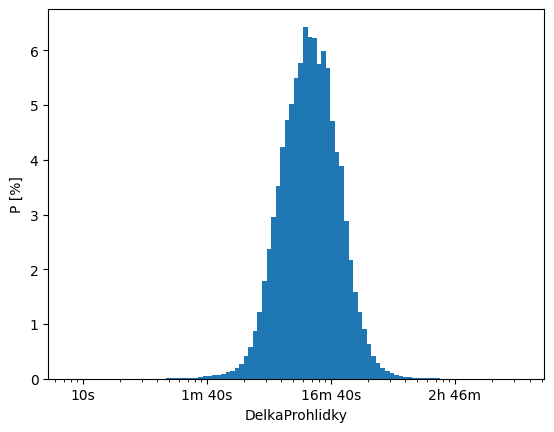

In [9]:
duration_s = (
    duration.select(pl.col('DelkaProhlidky').dt.total_seconds())
    .filter(pl.col('DelkaProhlidky') > 0)
    ['DelkaProhlidky'].to_pandas()
)
n_bins = 100
bins = np.logspace(np.log10(duration_s.min()), np.log10(duration_s.max()), n_bins)
weights = np.ones_like(duration_s) / len(duration_s) * n_bins
fig, ax = plt.subplots()
ax.hist(duration_s, bins=bins, weights=weights)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(FuncFormatter(sec_to_hms))
ax.set_xlabel('DelkaProhlidky')
ax.set_ylabel('P [%]')
plt.show()

# Roztřízeni dat na základě stavu OBD

In [10]:
df_rizeny_obd = df.filter(pl.col('EmisniSystem') == 'Rizeny_Obd')
short_display(df_rizeny_obd)
display_counts(df_rizeny_obd)

(7904517, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-160601-25-09-0059,2025-09-05,160601,2025-09-05 07:10:01.287,2025-09-05 07:16:23.670,96821,CZ-160601-25-09-0059,2025-09-05 07:16:00.000000,ATAL s.r.o.,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CZ-420619-19-05-0119,2019-05-10,420619,2019-05-10 11:34:23.043,2019-05-10 11:40:05.963,47163,CZ-420619-19-05-0119,2019-05-10 11:37:00.000000,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CZ-460513-21-03-0071,2021-03-03,460513,2021-03-03 06:45:38.210,2021-03-03 06:57:51.943,37587,CZ-460513-21-03-0071,2021-03-03 06:49:00.000000,Bosch,BEA070,...,0.71,1.0,0.00,1.0,2381.0,1.0,552.0,1.0,0.0,1.0
3,CZ-480345-20-10-0592,2020-10-16,480345,2020-10-16 14:29:32.633,2020-10-16 14:36:55.387,62769,CZ-480345-20-10-0592,2020-10-16 14:33:00.000000,Bosch,RTM430,...,0.42,1.0,0.03,1.0,2500.0,1.0,880.0,1.0,0.0,1.0
4,CZ-460634-20-04-0188,2020-04-14,460634,2020-04-14 06:40:36.267,2020-04-14 07:01:22.660,35091,CZ-460634-20-04-0188,2020-04-14 06:52:00.000000,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CZ-570216-23-05-0250,2023-05-16,570216,2023-05-16 09:54:23.043,2023-05-16 10:00:17.763,36497,CZ-570216-23-05-0250,2023-05-16 10:00:07.200293,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CZ-450815-24-02-0358,2024-02-29,450815,2024-02-29 12:08:53.557,2024-02-29 12:19:53.493,88905,CZ-450815-24-02-0358,2024-02-29 12:11:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,2.82,1.0,0.27,1.0,5100.0,1.0,850.0,1.0,96.0,1.0
7,CZ-461016-24-08-0498,2024-08-22,461016,2024-08-22 10:22:26.217,2024-08-22 10:32:24.230,30943,CZ-461016-24-08-0498,2024-08-22 10:32:23.466163,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,CZ-580803-21-06-0125,2021-06-21,580803,2021-06-21 13:12:32.793,2021-06-21 13:19:02.080,16083,CZ-580803-21-06-0125,2021-06-21 12:20:00.000000,ActiaCZ,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,CZ-440213-22-01-0142,2022-01-13,440213,2022-01-13 14:56:34.613,2022-01-13 15:21:52.423,36503,CZ-440213-22-01-0142,2022-01-13 15:17:01.000000,BOSCH,BEA070,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,0
CisloProtokolu,7904517
DatumProhlidky,7904517
StaniceCislo,7904517
Zahajeni,7867741
Ukonceni,7867741
...,...
Nafta_Mereni3_OtackyPrebehove_Vysledek,1463482
Nafta_Mereni3_OtackyVolnobezne_Hodnota,1463482
Nafta_Mereni3_OtackyVolnobezne_Vysledek,1463482
Nafta_Mereni3_Teplota_Hodnota,1246108


In [11]:
df_rizeny = df.filter(pl.col('EmisniSystem') == 'Rizeny')
short_display(df_rizeny)
display_counts(df_rizeny)

(1788884, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-440810-22-04-0263,2022-04-29,440810,2022-04-29 09:37:53.003,2022-04-29 09:55:06.770,194,CZ-440810-22-04-0263,2022-04-29 09:52:35.217563,Bosch,BEA 950,...,1.82,1.0,0.31,1.0,5060.0,1.0,911.0,1.0,82.0,2.0
1,CZ-460238-23-06-0224,2023-06-20,460238,2023-06-20 12:38:07.910,2023-06-20 12:45:21.660,1063,CZ-460238-23-06-0224,2023-06-20 12:44:00.000000,ACTIA CZ s.r.o.,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CZ-560307-21-06-0392,2021-06-16,560307,2021-06-16 11:55:01.353,2021-06-16 12:26:57.903,40889,CZ-560307-21-06-0392,2021-06-16 12:01:00.000000,AVL DiTEST GmbH,DSS OM-CZ,...,2.06,1.0,0.71,0.0,2610.0,1.0,710.0,1.0,NaN,NaN
3,CZ-580107-23-12-0246,2023-12-12,580107,2023-12-12 07:08:12.597,2023-12-12 07:20:43.430,36957,CZ-580107-23-12-0246,2023-12-12 07:12:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,2.35,1.0,0.10,1.0,4800.0,1.0,840.0,1.0,80.0,1.0
4,CZ-540514-20-02-0842,2020-02-10,540514,2020-02-10 08:45:43.610,2020-02-10 08:52:11.723,2381,CZ-540514-20-02-0842,2020-02-10 08:47:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,1.12,1.0,1.02,1.0,4880.0,1.0,800.0,1.0,69.0,1.0
5,CZ-430824-19-04-0336,2019-04-15,430824,2019-04-15 08:32:21.617,2019-04-15 08:34:34.390,40315,CZ-430824-19-04-0336,2019-04-15 08:21:00.000000,Bosch,BEA070,...,1.56,1.0,0.29,1.0,4811.0,1.0,806.0,1.0,0.0,1.0
6,CZ-420932-22-02-0732,2022-02-28,420932,2022-02-28 07:07:45.703,2022-02-28 07:29:43.520,37137,CZ-420932-22-02-0732,2022-02-28 07:28:29.190255,Bosch,BEA 950,...,4.08,1.0,0.86,1.0,4800.0,1.0,875.0,1.0,83.0,2.0
7,CZ-470905-22-07-0246,2022-07-21,470905,2022-07-21 09:47:46.187,2022-07-21 09:58:07.580,21061,CZ-470905-22-07-0246,2022-07-21 09:47:46.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,0.89,1.0,0.08,1.0,4700.0,1.0,850.0,1.0,NaN,NaN
8,CZ-570415-19-03-0195,2019-03-21,570415,2019-03-21 11:27:20.183,2019-03-21 11:39:21.140,36941,CZ-570415-19-03-0195,2019-03-21 11:33:00.000000,BRAIN BEE,OPA-100,...,2.98,1.0,0.83,1.0,2610.0,1.0,820.0,1.0,0.0,1.0
9,CZ-571313-20-11-0002,2020-11-02,571313,2020-11-02 07:00:39.393,2020-11-02 07:06:22.770,37777,CZ-571313-20-11-0002,2020-11-02 07:03:00.000000,BRAIN BEE,OPA-100,...,0.79,1.0,0.59,1.0,4820.0,1.0,870.0,1.0,76.0,1.0


,0
CisloProtokolu,1788884
DatumProhlidky,1788884
StaniceCislo,1788884
Zahajeni,1766670
Ukonceni,1766670
...,...
Nafta_Mereni3_OtackyPrebehove_Vysledek,1751648
Nafta_Mereni3_OtackyVolnobezne_Hodnota,1751648
Nafta_Mereni3_OtackyVolnobezne_Vysledek,1751648
Nafta_Mereni3_Teplota_Hodnota,1429882


In [12]:
df_nerizeny = df.filter(pl.col('EmisniSystem') == 'Nerizeny')
short_display(df_nerizeny)
display_counts(df_nerizeny)

(538829, 139)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-571204-19-03-0205,2019-03-19,571204,2019-03-19 11:25:25.760,2019-03-19 11:46:20.097,43613,CZ-571204-19-03-0205,2019-03-19 11:25:30.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,0.94,1,0.52,1,3260.0,1,760.0,1,NaN,NaN
1,CZ-471038-19-11-0046,2019-11-11,471038,2019-11-11 07:07:53.880,2019-11-11 07:20:41.697,2843,CZ-471038-19-11-0046,2019-11-11 07:12:00.000000,Bosch,BEA070,...,0.45,1,0.33,1,2105.0,1,510.0,1,0.0,1.0
2,CZ-530203-19-01-0244,2019-01-22,530203,2019-01-22 08:29:31.203,2019-01-22 08:31:50.023,43333,CZ-530203-19-01-0244,2019-01-22 00:00:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,0.62,1,2.87,1,3170.0,1,910.0,1,NaN,NaN
3,CZ-570704-20-03-0018,2020-03-11,570704,2020-03-11 09:31:46.370,2020-03-11 09:59:43.410,812,CZ-570704-20-03-0018,2020-03-11 09:44:04.000000,BOSCH,BEA-PC,...,1.75,1,1.14,0,2405.0,1,540.0,1,NaN,NaN
4,CZ-450707-21-06-0137,2021-06-09,450707,2021-06-09 06:38:49.787,2021-06-09 06:59:59.207,52605,CZ-450707-21-06-0137,2021-06-09 06:44:00.000000,BOSCH,BEA-PC,...,0.82,1,0.56,0,2308.0,1,580.0,1,NaN,NaN
5,CZ-480714-22-06-0520,2022-06-10,480714,2022-06-10 09:09:19.927,2022-06-10 09:41:29.853,41171,CZ-480714-22-06-0520,2022-06-10 09:28:11.709163,Bosch,BEA 950,...,1.84,1,0.50,1,2150.0,1,604.0,1,81.0,2.0
6,CZ-570509-23-09-0052,2023-09-25,570509,2023-09-25 08:53:30.693,2023-09-25 09:10:49.700,1267,CZ-570509-23-09-0052,2023-09-25 09:07:56.733490,Bosch,BEA 950,...,1.36,1,0.34,1,2280.0,1,750.0,1,81.0,2.0
7,CZ-480406-19-12-0167,2019-12-16,480406,2019-12-16 07:46:04.997,2019-12-16 08:00:01.520,36909,CZ-480406-19-12-0167,2019-12-16 07:55:00.000000,Bosch,RTM430,...,1.93,1,0.02,1,2479.0,1,798.0,1,0.0,1.0
8,CZ-180502-25-05-0317,2025-05-22,180502,2025-05-22 13:12:15.890,2025-05-22 13:43:42.533,16553,CZ-180502-25-05-0317,2025-05-22 13:33:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,2.17,1,1.48,1,2430.0,1,550.0,1,89.0,1.0
9,CZ-580521-22-09-0021,2022-09-07,580521,2022-09-07 10:22:59.953,2022-09-07 10:33:53.343,8087,CZ-580521-22-09-0021,2022-09-07 10:23:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,0.77,1,0.86,1,2970.0,1,790.0,1,89.0,1.0


,0
CisloProtokolu,538829
DatumProhlidky,538829
StaniceCislo,538829
Zahajeni,465292
Ukonceni,465292
...,...
Nafta_Mereni3_OtackyPrebehove_Vysledek,536255
Nafta_Mereni3_OtackyVolnobezne_Hodnota,536255
Nafta_Mereni3_OtackyVolnobezne_Vysledek,536255
Nafta_Mereni3_Teplota_Hodnota,464406


In [13]:
# df_pd_rizeny_obd = get_short(df_rizeny_obd).to_pandas()
# rizeny_obd_profile = ProfileReport(df_pd_rizeny_obd, title="Nafta osobní vozidla minimálni verze", minimal=True)
# rizeny_obd_profile.to_file('report.html')

In [13]:
short_display(df_all.filter(pl.col('CisloProtokolu') == 'CZ-540308-24-02-0512'))

(2, 143)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek,Benzin_PocetVyusteni,Plyn_PocetVyusteni,Obd_Readiness_J1939_Pritomno,Obd_Readiness_Zazeh_Pritomno
0,CZ-540308-24-02-0512,2024-02-14,3420,2024-02-14 06:53:19.297,2024-02-14 07:09:35.900,69281,CZ-540308-24-02-0512,2024-02-14 07:08:34.888717,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False
1,CZ-540308-24-02-0512,2024-02-14,540308,2024-02-14 06:53:19.297,2024-02-14 07:09:35.900,102209,CZ-540308-24-02-0512,2024-02-14 07:08:34.888717,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,False,False


In [6]:
cislo_protokolu_technicka = set(df_technicka.select(pl.col('Emise_CisloProtokolu').str.replace(r'^CZ-(0+)(\d+)', r'CZ-${2}'))['Emise_CisloProtokolu'])
cislo_protokolu_mereni = set(df_all.select(pl.col('CisloProtokolu').str.replace(r'^CZ-(0+)(\d+)', r'CZ-${2}'))['CisloProtokolu'])
cislo_protokolu_mereni - cislo_protokolu_technicka

{'CZ-120902-20-07-0174', 'CZ-410432-20-08-0152'}

In [7]:
df_all['Vozidlo_Palivo'].value_counts()

Vozidlo_Palivo,count
str,u32
"""BNB""",8
"""NM""",685379
"""N""",148321
null,1216
"""BA""",2
